In [1]:
# ============================================================
# IMPORTS
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

# ============================================================
# LOAD FIELD MAPS
# ============================================================

project_root = Path.cwd().parent
data_dir = project_root / "data"

# ------------------------------------------------------------
# z = 0 maps
# ------------------------------------------------------------

data_0 = np.load(
    data_dir / "field_maps_z0.npz",
    allow_pickle=True
)

field_maps_0 = data_0['field_maps'].item()

X = data_0['X']
Y = data_0['Y']

print("Loaded field maps.")

Loaded field maps.


In [2]:
# ============================================================
# OPTIMIZED CURRENTS
# ============================================================

currents = {

    'X1': 68,
    'X2': 32,
    'X3': 68,

    'Y1': -23,
    'Y2': -23,

    'Z1': 72,
    'Z2': 72
}

In [3]:
# ============================================================
# AMBIENT FIELD (mG)
# ============================================================

Bx_ambient = -283.38
By_ambient =  106.79
Bz_ambient = -381.21

In [4]:
# ============================================================
# BUILD TOTAL FIELD MAPS
# ============================================================

Bx_total = np.zeros_like(X)
By_total = np.zeros_like(X)
Bz_total = np.zeros_like(X)

for coil_name, I in currents.items():

    Bx_total += I * field_maps_0[coil_name]['Bx']
    By_total += I * field_maps_0[coil_name]['By']
    Bz_total += I * field_maps_0[coil_name]['Bz']

# ------------------------------------------------------------
# ADD AMBIENT FIELD
# ------------------------------------------------------------

Bx_total += Bx_ambient
By_total += By_ambient
Bz_total += Bz_ambient

# ------------------------------------------------------------
# TOTAL MAGNITUDE
# ------------------------------------------------------------

Bmag_total = np.sqrt(

    Bx_total**2 +
    By_total**2 +
    Bz_total**2
)

print("Total field maps built.")

Total field maps built.


In [5]:
# ============================================================
# PMT2 CENTER
# ============================================================

xc = -0.760
yc =  0.000
zc =  0.000

# ============================================================
# LOCAL SAMPLING GRID
# ============================================================

dx = np.array([-0.2, -0.1, 0.0, 0.1, 0.2])
dy = np.array([-0.2, -0.1, 0.0, 0.1, 0.2])

# ------------------------------------------------------------
# CREATE 5x5 GRID
# ------------------------------------------------------------

X_local, Y_local = np.meshgrid(

    xc + dx,
    yc + dy
)

print("Sampling grid created.")

Sampling grid created.


In [6]:
# ============================================================
# EXTRACT LOCAL FIELD VALUES
# ============================================================

Bx_local = np.zeros_like(X_local)
By_local = np.zeros_like(X_local)
Bz_local = np.zeros_like(X_local)
Bmag_local = np.zeros_like(X_local)

# ------------------------------------------------------------
# FIND NEAREST GRID POINTS
# ------------------------------------------------------------

for i in range(X_local.shape[0]):

    for j in range(X_local.shape[1]):

        x_target = X_local[i, j]
        y_target = Y_local[i, j]

        # nearest indices

        ix = np.argmin(np.abs(X[0, :] - x_target))
        iy = np.argmin(np.abs(Y[:, 0] - y_target))

        # extract fields

        Bx_local[i, j] = Bx_total[iy, ix]
        By_local[i, j] = By_total[iy, ix]
        Bz_local[i, j] = Bz_total[iy, ix]
        Bmag_local[i, j] = Bmag_total[iy, ix]

print("Local PMT fields extracted.")

Local PMT fields extracted.


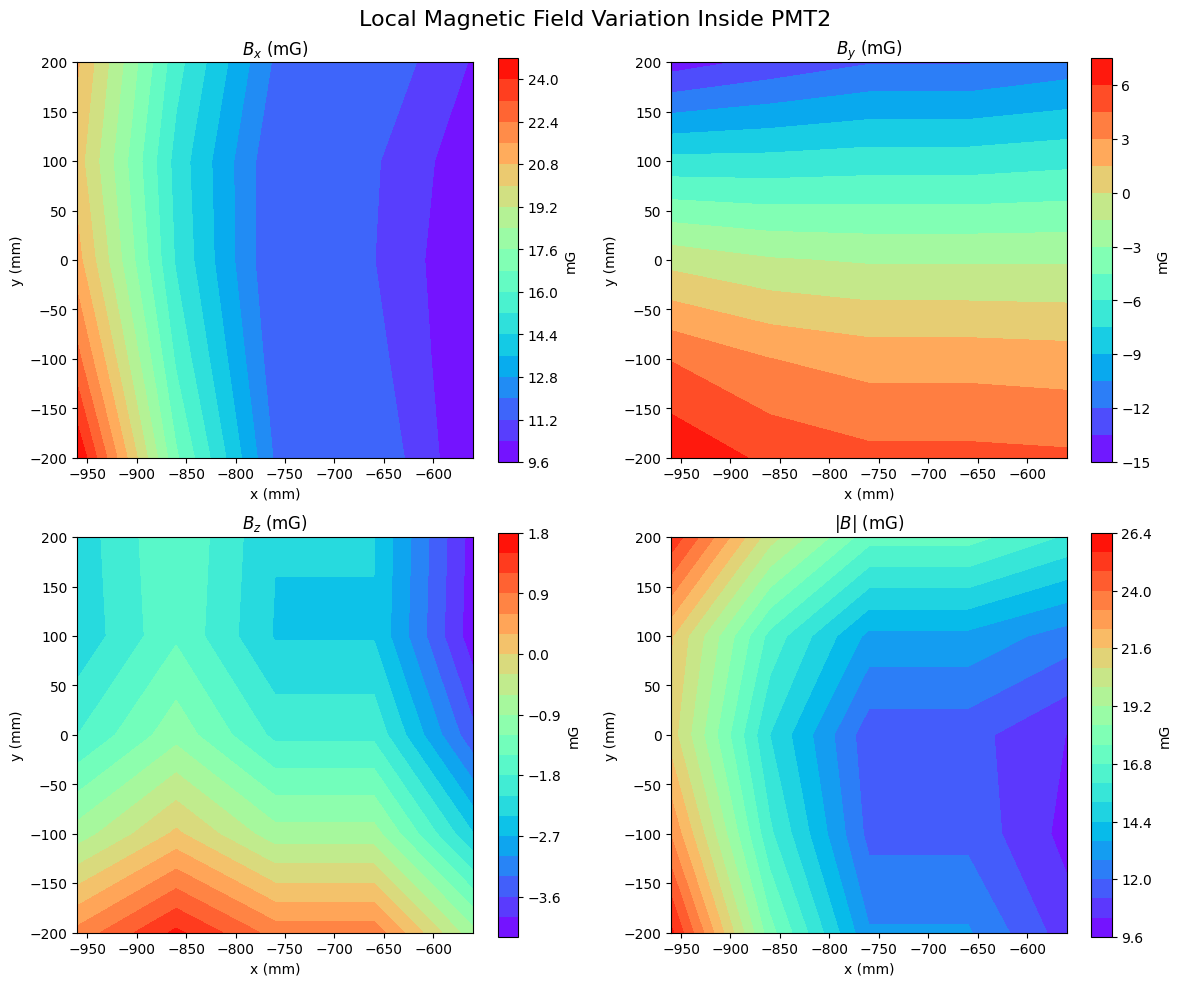

In [7]:
# ============================================================
# LOCAL FIELD HEATMAPS
# ============================================================

fig, axes = plt.subplots(

    2,
    2,

    figsize=(12,10)
)

plots = [

    (Bx_local, r'$B_x$ (mG)'),
    (By_local, r'$B_y$ (mG)'),
    (Bz_local, r'$B_z$ (mG)'),
    (Bmag_local, r'$|B|$ (mG)')
]

for ax, (data, title) in zip(axes.flat, plots):

    im = ax.contourf(

        X_local * 1000,
        Y_local * 1000,

        data,

        levels=20,
        cmap='rainbow'
    )

    cbar = plt.colorbar(im, ax=ax)

    cbar.set_label('mG')

    ax.set_title(title)

    ax.set_xlabel('x (mm)')
    ax.set_ylabel('y (mm)')

    ax.set_aspect('equal')

plt.suptitle(

    'Local Magnetic Field Variation Inside PMT2',
    fontsize=16
)

plt.tight_layout()

plt.show()

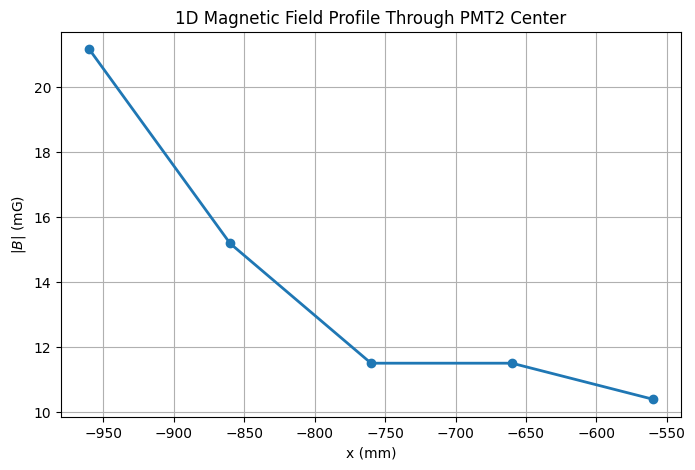

In [8]:
# ============================================================
# 1D PROFILE THROUGH PMT CENTER
# ============================================================

center_row = 2

x_profile = X_local[center_row, :] * 1000

B_profile = Bmag_local[center_row, :]

plt.figure(figsize=(8,5))

plt.plot(

    x_profile,
    B_profile,

    'o-',
    linewidth=2
)

plt.xlabel('x (mm)')
plt.ylabel(r'$|B|$ (mG)')

plt.title(

    '1D Magnetic Field Profile Through PMT2 Center'
)

plt.grid(True)

plt.show()

This plot shows:

how much field changes across the PMT diameter.

Flat line:

 - excellent uniformity.

Steep variation:

 - poor compensation.

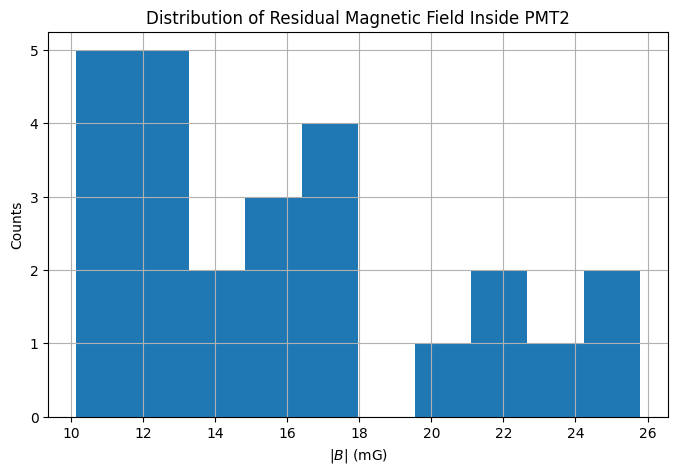

In [9]:
# ============================================================
# HISTOGRAM OF LOCAL FIELD MAGNITUDES
# ============================================================

plt.figure(figsize=(8,5))

plt.hist(

    Bmag_local.flatten(),

    bins=10
)

plt.xlabel(r'$|B|$ (mG)')
plt.ylabel('Counts')

plt.title(

    'Distribution of Residual Magnetic Field Inside PMT2'
)

plt.grid(True)

plt.show()

This shows:

spread of residual field values
field uniformity quality.

Narrow histogram:

good compensation.

Wide histogram:

strong gradients.

In [10]:
# ============================================================
# LOCAL FIELD STATISTICS
# ============================================================

B_values = Bmag_local.flatten()

# ------------------------------------------------------------
# MEAN FIELD
# ------------------------------------------------------------

B_mean = np.mean(B_values)

# ------------------------------------------------------------
# RMS VARIATION
# ------------------------------------------------------------

B_rms = np.std(B_values)

# ------------------------------------------------------------
# MAX-MIN VARIATION
# ------------------------------------------------------------

B_variation = np.max(B_values) - np.min(B_values)

# ============================================================
# PRINT RESULTS
# ============================================================

print("================================================")
print("LOCAL FIELD UNIFORMITY INSIDE PMT2")
print("================================================")

print(f"Mean residual field      : {B_mean:.2f} mG")

print(f"RMS field variation      : {B_rms:.2f} mG")

print(f"Max-Min field variation  : {B_variation:.2f} mG")

LOCAL FIELD UNIFORMITY INSIDE PMT2
Mean residual field      : 15.85 mG
RMS field variation      : 4.63 mG
Max-Min field variation  : 15.65 mG


Compare this to Earth field:

∣B
earth
	​

∣∼500 mG

So you reduced:

from ~500 mG
to ~16 mG.

That is:

∼97%

suppression.